In [53]:
from pathlib import Path
import random, json
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 31
random.seed(SEED)
np.random.seed(SEED)

# I/O paths
DATA_DIR      = Path("algorithm_selection_data_seed_123")
META_DIR      = Path("metafeatures")
LABELS_CSV    = DATA_DIR / "algorithm_selection_labels.csv"
TARGETS_OUT   = "algorithm_targets.csv"

# Meta-feature sources
META_FILES = {
    "x1": META_DIR / "meta-features-split-0.csv",
    "x2": META_DIR / "meta-features-split-1.csv",
    "x3": META_DIR / "meta-features-split-2.csv",
    "x4": META_DIR / "meta-features-split-3.csv",
    "x5": META_DIR / "meta-features-split-4.csv",
    "x6": META_DIR / "mf1.csv",
    "x7": META_DIR / "mf2.csv",
}


In [54]:
df_labels = pd.read_csv(LABELS_CSV)

le = LabelEncoder()
df_labels["target"] = le.fit_transform(df_labels["best_algorithm"])

target_df = (
    df_labels[["dataset", "target"]]
    .set_index("dataset")
    .sort_index()
)
target_df.to_csv(TARGETS_OUT)        # cache for joins

# Majority-class baseline
majority_algorithm = df_labels["best_algorithm"].mode()[0]
majority_count     = (df_labels["best_algorithm"] == majority_algorithm).sum()
majority_acc       = majority_count / len(df_labels)

majority_info = {
    "algorithm": str(majority_algorithm),
    "encoded"  : int(le.transform([majority_algorithm])[0]),
    "count"    : int(majority_count),
    "accuracy" : float(majority_acc)
}

print(json.dumps(majority_info, indent=2))


{
  "algorithm": "RandomForest",
  "encoded": 2,
  "count": 50,
  "accuracy": 0.4166666666666667
}


In [55]:
# Cell 3  |  Create datasets dictionary {name: DataFrame}
def load_meta_datasets(meta_files: dict, target_csv: str) -> dict:
    """Join every meta-feature CSV with the encoded targets."""
    targets = pd.read_csv(target_csv, index_col=0)
    datasets = {}
    for name, path in meta_files.items():
        meta = pd.read_csv(path, index_col=0)
        datasets[name] = meta.join(targets, how="inner")
    return datasets

datasets = load_meta_datasets(META_FILES, TARGETS_OUT)
for k, v in datasets.items():
    print(f"{k}: {v.shape}")


x1: (120, 33)
x2: (120, 33)
x3: (120, 33)
x4: (120, 33)
x5: (120, 33)
x6: (120, 42)
x7: (120, 23)


In [56]:
def evaluate_dataset(df, seed):
    X, y = df.iloc[:, :-1].values, df.iloc[:, -1].values
    loo = LeaveOneOut()
    clf = RandomForestClassifier(random_state=seed)

    correct = 0
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]

        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        correct += int(y_pred[0] == y_test[0])

    return correct / len(X)


In [57]:
N_REPEATS = 10
results = {}

for name in sorted(datasets):
    print(f"Evaluating {name} ...")
    scores = []
    for rep in range(N_REPEATS):
        seed = SEED + rep
        acc = evaluate_dataset(datasets[name], seed)
        scores.append(acc)
    results[name] = scores
    print(f"  Mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}")



Evaluating x1 ...
  Mean: 0.4417 ± 0.0201
Evaluating x2 ...
  Mean: 0.5483 ± 0.0182
Evaluating x3 ...
  Mean: 0.4933 ± 0.0162
Evaluating x4 ...
  Mean: 0.4400 ± 0.0148
Evaluating x5 ...
  Mean: 0.4908 ± 0.0120
Evaluating x6 ...
  Mean: 0.4908 ± 0.0231
Evaluating x7 ...
  Mean: 0.4850 ± 0.0247


In [58]:
# Cell 6  |  Combine deep (x1-x5) with crafted (x6, x7)
hybrid_map = {}
counter = 8
for deep in ["x1","x2","x3","x4","x5"]:
    for crafted in ["x6","x7"]:
        deep_df     = datasets[deep].iloc[:, :-1]
        crafted_df  = datasets[crafted].iloc[:, :-1]
        hybrid_name = f"x{counter}"
        hybrid_df   = pd.concat([deep_df, crafted_df], axis=1)
        hybrid_df["target"] = datasets[deep]["target"]
        datasets[hybrid_name] = hybrid_df
        hybrid_map[hybrid_name] = f"{deep}+{crafted}"
        counter += 1

print("Hybrid combos:", hybrid_map)


Hybrid combos: {'x8': 'x1+x6', 'x9': 'x1+x7', 'x10': 'x2+x6', 'x11': 'x2+x7', 'x12': 'x3+x6', 'x13': 'x3+x7', 'x14': 'x4+x6', 'x15': 'x4+x7', 'x16': 'x5+x6', 'x17': 'x5+x7'}


In [60]:
# Cell 7  |  Evaluation loop for hybrids with repeated runs
for name in sorted(hybrid_map):
    print(f"Evaluating {name} ({hybrid_map[name]}) ...")
    scores = []
    for rep in range(N_REPEATS):
        seed = SEED + rep
        acc = evaluate_dataset(datasets[name], seed)
        scores.append(acc)
    results[name] = scores
    print(f"  Mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Evaluating x10 (x2+x6) ...
  Mean: 0.4925 ± 0.0160
Evaluating x11 (x2+x7) ...
  Mean: 0.4942 ± 0.0179
Evaluating x12 (x3+x6) ...
  Mean: 0.4875 ± 0.0136
Evaluating x13 (x3+x7) ...
  Mean: 0.4858 ± 0.0099
Evaluating x14 (x4+x6) ...
  Mean: 0.4850 ± 0.0170
Evaluating x15 (x4+x7) ...
  Mean: 0.4725 ± 0.0167
Evaluating x16 (x5+x6) ...
  Mean: 0.4917 ± 0.0162
Evaluating x17 (x5+x7) ...
  Mean: 0.4942 ± 0.0233
Evaluating x8 (x1+x6) ...
  Mean: 0.4833 ± 0.0139
Evaluating x9 (x1+x7) ...
  Mean: 0.4850 ± 0.0104


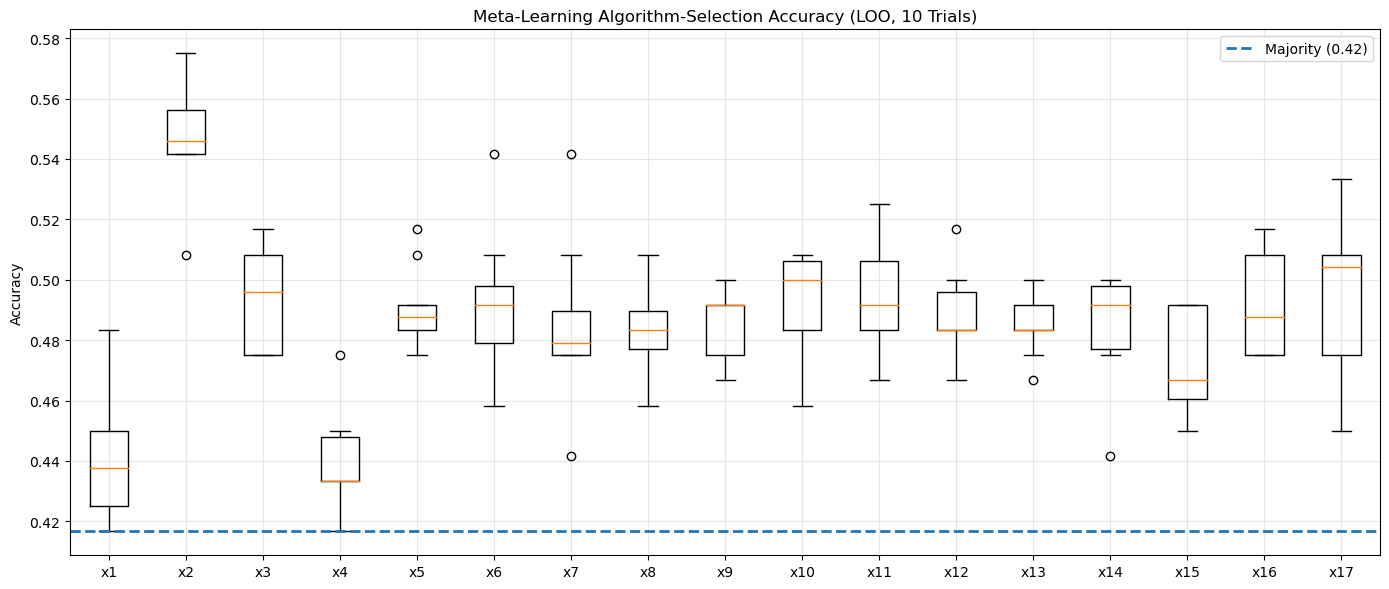

In [62]:
# Cell 8 | Boxplot of repeated results
plt.figure(figsize=(14, 6))
order = sorted(results, key=lambda x: int(x[1:]))
plt.boxplot([results[k] for k in order], labels=order)
plt.axhline(majority_acc, ls="--", lw=2, label=f"Majority ({majority_acc:.2f})")
plt.title("Meta-Learning Algorithm-Selection Accuracy (LOO, 10 Trials)")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
ranked = sorted(
    ((k, np.mean(v), np.std(v)) for k, v in results.items()),
    key=lambda t: t[1], reverse=True
)
pd.DataFrame(ranked, columns=["Set", "MeanAcc", "StdDev"]).style.background_gradient(cmap="Greens")


,Set,MeanAcc,StdDev
0,x2,0.548333,0.018181
1,x11,0.494167,0.017892
2,x17,0.494167,0.023289
3,x3,0.493333,0.016159
4,x10,0.492500,0.016008
5,x16,0.491667,0.016245
6,x6,0.490833,0.023109
7,x5,0.490833,0.012047
8,x12,0.487500,0.013566
9,x13,0.485833,0.009895
